In [1]:
MULTIRUN_PATH = "/home/riccardorota/PACS/PACSproject/multirun/2025-11-02/21-23-54"
#MULTIRUN_PATH = "/home/riccardorota/PACS/PACSproject/multirun/2025-11-02/22-02-59"

In [2]:
import pandas as pd
import json
from pathlib import Path
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def flatten_data(data, parent_key='', sep='_'):
    items = []
    for k, v in data.items():
        if k == 'training_history':
            continue
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_data(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)

In [4]:
def compile_hydra_runs(multirun_dir):
    root_path = Path(multirun_dir)
    json_filename = "run_data.json"
    json_files = list(root_path.rglob(json_filename))
    all_runs_data = []
    for file_path in json_files:
        with open(file_path, 'r') as f:
            run_data = json.load(f)
        flat_data = flatten_data(run_data)
        flat_data['run_directory'] = str(file_path.parent.relative_to(root_path))
        all_runs_data.append(flat_data)
    df = pd.DataFrame(all_runs_data)
    return df

In [5]:
df_results = compile_hydra_runs(MULTIRUN_PATH)
df_results['target_hidden_layer_size'] = df_results['targetnetwork_num_neurons'].apply(lambda x: x[1])

display(df_results.head())

,f_to_learn,test_metrics_RRMSE,test_metrics_MAE,test_metrics_RMSE,val_metrics_loss,val_metrics_MAE,val_metrics_RMSE,val_metrics_RRMSE,train_metrics_loss,train_metrics_MAE,...,hypernetwork_type,hypernetwork_num_parameters,hypernetwork_num_neurons,targetnetwork_type,targetnetwork_num_parameters,targetnetwork_num_neurons,N,n_realizations,run_directory,target_hidden_layer_size
0,"lambda mu, l, k, x: jnp.exp(-l*x) + mu*x + k*x**2",0.732504,0.665584,0.879921,0.404419,0.678088,0.894888,0.744969,0.374977,0.678013,...,MLP,54145,"[3, 64, 64, 128, 321]",Siren,321,"[1, 16, 16, 1]",1000,10,21,16
1,"lambda mu, l, k, x: jnp.exp(-l*x) + mu*x + k*x**2",0.793813,0.694562,0.926652,0.414893,0.919781,1.242812,1.064339,0.452606,0.917809,...,MLP,161473,"[3, 64, 64, 128, 1153]",Siren,1153,"[1, 32, 32, 1]",100,10,10,32
2,"lambda mu, l, k, x: jnp.exp(-l*x) + mu*x + k*x**2",0.078580,0.013493,0.092967,0.003034,0.015604,0.100254,0.084741,0.000095,0.015603,...,MLP,574273,"[3, 64, 64, 128, 4353]",MLP,4353,"[1, 64, 64, 1]",1000,1,14,64
3,"lambda mu, l, k, x: jnp.exp(-l*x) + mu*x + k*x**2",0.042053,0.014892,0.050516,0.000046,0.017745,0.059945,0.049902,0.000028,0.017740,...,MLP,574273,"[3, 64, 64, 128, 4353]",MLP,4353,"[1, 64, 64, 1]",1000,10,20,64
4,"lambda mu, l, k, x: jnp.exp(-l*x) + mu*x + k*x**2",0.788854,0.687979,0.909744,0.234254,0.721853,0.955437,0.828451,0.328230,0.721822,...,MLP,574273,"[3, 64, 64, 128, 4353]",Siren,4353,"[1, 64, 64, 1]",100,1,5,64


In [6]:
df_results.targetnetwork_num_neurons.value_counts()

targetnetwork_num_neurons
[1, 16, 16, 1]    8
[1, 32, 32, 1]    8
[1, 64, 64, 1]    8
Name: count, dtype: int64

In [7]:
df_results.train_dataset_size.value_counts()

train_dataset_size
800     12
8000     6
80       6
Name: count, dtype: int64

In [8]:
df_results.targetnetwork_type.value_counts()

targetnetwork_type
Siren    12
MLP      12
Name: count, dtype: int64

In [9]:
df_results.keys()

Index(['f_to_learn', 'test_metrics_RRMSE', 'test_metrics_MAE',
       'test_metrics_RMSE', 'val_metrics_loss', 'val_metrics_MAE',
       'val_metrics_RMSE', 'val_metrics_RRMSE', 'train_metrics_loss',
       'train_metrics_MAE', 'train_metrics_RMSE', 'train_metrics_RRMSE',
       'early_stopping_triggered', 'num_epochs', 'best_epoch',
       'training_time_seconds', 'time_per_epoch_seconds', 'train_dataset_size',
       'hypernetwork_type', 'hypernetwork_num_parameters',
       'hypernetwork_num_neurons', 'targetnetwork_type',
       'targetnetwork_num_parameters', 'targetnetwork_num_neurons', 'N',
       'n_realizations', 'run_directory', 'target_hidden_layer_size'],
      dtype='object')

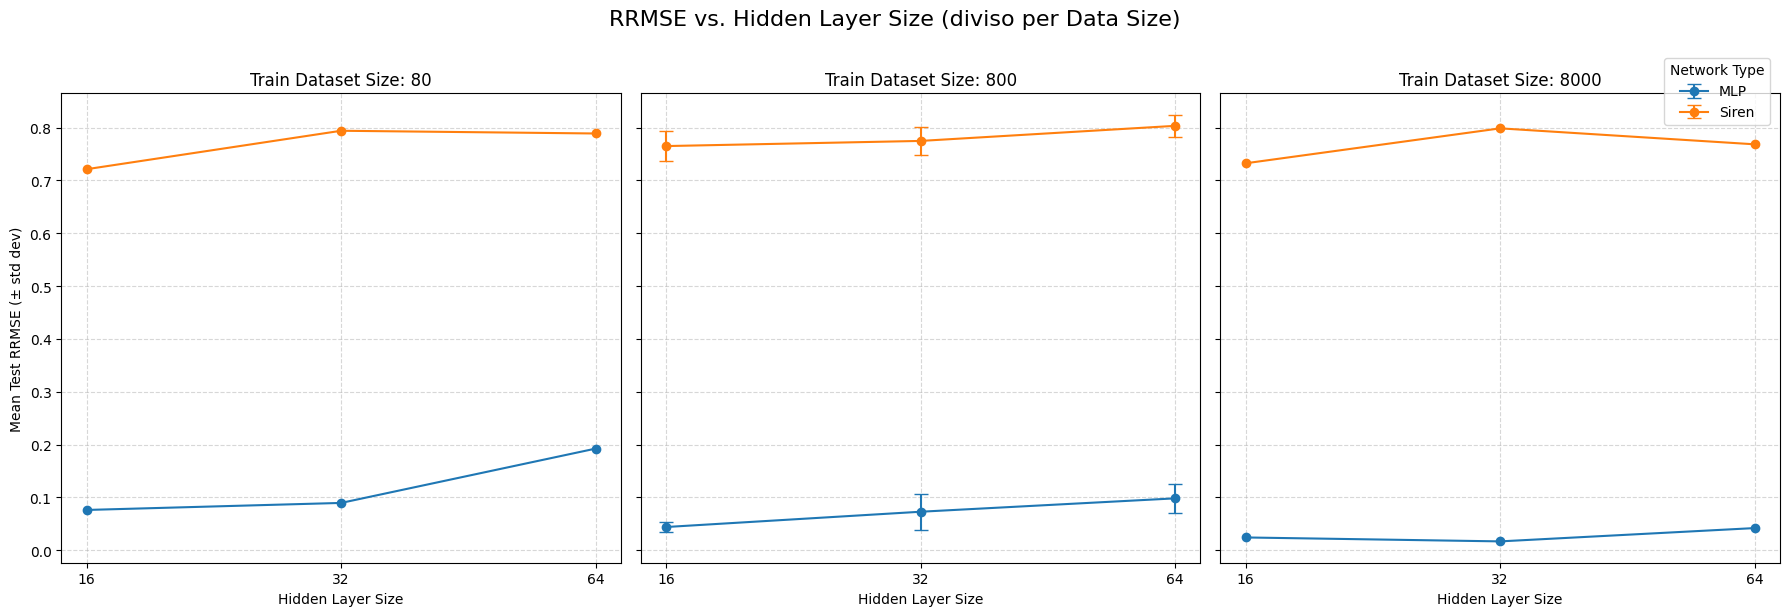

In [10]:
dataset_sizes = sorted(df_results['train_dataset_size'].unique()) # [80, 800, 8000]
hidden_sizes = sorted(df_results['target_hidden_layer_size'].dropna().unique())   # [16, 32, 64]
network_types = ['MLP', 'Siren']

fig, axes = plt.subplots(1, len(dataset_sizes), figsize=(18, 6), sharey=True)

for i, size in enumerate(dataset_sizes):
    ax = axes[i] if len(dataset_sizes) > 1 else axes
    for net_type in network_types:
        df_subset = df_results[(df_results['train_dataset_size'] == size) & (df_results['targetnetwork_type'] == net_type)]
        grouped_data = df_subset.groupby('target_hidden_layer_size')['test_metrics_RRMSE'].agg(['mean', 'std']).reset_index()
        grouped_data = grouped_data.sort_values(by='target_hidden_layer_size')
        ax.errorbar(
            grouped_data['target_hidden_layer_size'],
            grouped_data['mean'],
            yerr=grouped_data['std'], 
            label=net_type, 
            marker='o',  # Punto
            capsize=5    # Baffi
        )
    ax.set_title(f'Train Dataset Size: {size}')
    ax.set_xlabel('Hidden Layer Size')
    ax.set_xscale('log', base=2)
    ax.set_xticks(hidden_sizes)
    ax.set_xticklabels(hidden_sizes)
    ax.grid(True, which="both", ls="--", alpha=0.5)

fig.suptitle('RRMSE vs. Hidden Layer Size (diviso per Data Size)', fontsize=16, y=1.02)
if len(dataset_sizes) > 1:
    axes[0].set_ylabel('Mean Test RRMSE (± std dev)')
else:
    axes.set_ylabel('Mean Test RRMSE (± std dev)')

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.99, 0.95), title="Network Type")

plt.tight_layout()
plt.show()

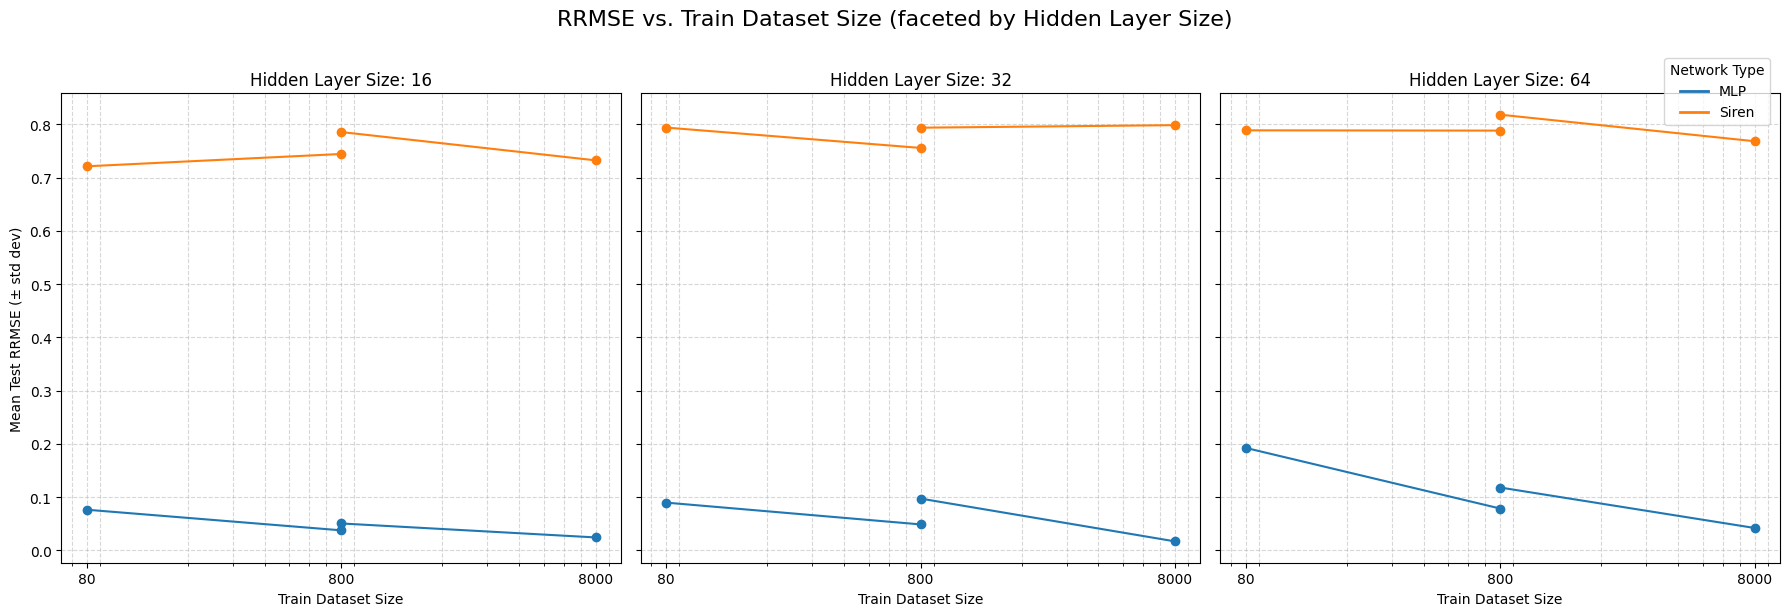

In [11]:
from matplotlib.lines import Line2D

hidden_sizes = sorted(df_results['target_hidden_layer_size'].dropna().unique())
dataset_sizes = sorted(df_results['train_dataset_size'].dropna().unique()) 
network_types = ['MLP', 'Siren']
realizations = sorted(df_results['n_realizations'].dropna().unique())

colors = {'MLP': 'C0', 'Siren': 'C1'} 

fig, axes = plt.subplots(1, len(hidden_sizes), figsize=(18, 6), sharey=True)

for i, h_size in enumerate(hidden_sizes):
    ax = axes[i] if len(hidden_sizes) > 1 else axes
    
    for net_type in network_types:
        for n_real in realizations:
            df_subset = df_results[
                (df_results['target_hidden_layer_size'] == h_size) &
                (df_results['targetnetwork_type'] == net_type) &
                (df_results['n_realizations'] == n_real)
            ]
            
            if df_subset.empty:
                continue
            
            grouped_data = df_subset.groupby('train_dataset_size')['test_metrics_RRMSE'].agg(['mean', 'std']).reset_index()
            grouped_data = grouped_data.sort_values(by='train_dataset_size')
            
            ax.errorbar(
                grouped_data['train_dataset_size'],
                grouped_data['mean'], 
                yerr=grouped_data['std'], 
                marker='o',
                capsize=5,
                color=colors[net_type], 
                linestyle='-'           
            )

    ax.set_title(f'Hidden Layer Size: {h_size}')
    ax.set_xlabel('Train Dataset Size')
    ax.set_xscale('log')
    ax.set_xticks(dataset_sizes)
    ax.set_xticklabels(dataset_sizes)
    ax.grid(True, which="both", ls="--", alpha=0.5)

fig.suptitle('RRMSE vs. Train Dataset Size (faceted by Hidden Layer Size)', fontsize=16, y=1.02)
axes[0].set_ylabel('Mean Test RRMSE (± std dev)')

legend_elements = [
    Line2D([0], [0], color=colors['MLP'], lw=2, label='MLP'),
    Line2D([0], [0], color=colors['Siren'], lw=2, label='Siren')
]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.99, 0.95), title="Network Type")

plt.tight_layout()
plt.show()

In [12]:
# find a run number
cond_N = (df_results['N'] == 1000)
cond_real = (df_results['n_realizations'] == 10)
cond_hidden = (df_results['target_hidden_layer_size'] == 16)
cond_type = (df_results['targetnetwork_type'] == 'MLP')

run = df_results[cond_N & cond_real & cond_hidden & cond_type]
run

,f_to_learn,test_metrics_RRMSE,test_metrics_MAE,test_metrics_RMSE,val_metrics_loss,val_metrics_MAE,val_metrics_RMSE,val_metrics_RRMSE,train_metrics_loss,train_metrics_MAE,...,hypernetwork_type,hypernetwork_num_parameters,hypernetwork_num_neurons,targetnetwork_type,targetnetwork_num_parameters,targetnetwork_num_neurons,N,n_realizations,run_directory,target_hidden_layer_size
9,"lambda mu, l, k, x: jnp.exp(-l*x) + mu*x + k*x**2",0.024316,0.012054,0.02921,0.00003,0.013713,0.033197,0.027635,0.000007,0.01371,...,MLP,54145,"[3, 64, 64, 128, 321]",MLP,321,"[1, 16, 16, 1]",1000,10,18,16
